# Low correlation, $S_{1/2}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import sys
from scipy.special import legendre
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sys.path.insert(1, '../../scripts')
import CMBanom

In [2]:
# Parameters
Nside  = 128
method = "summation"
load_stats_from_cluster = False

if load_stats_from_cluster: Nsims = 100000
else:                       Nsims = 1000

In [3]:
# Directories
sims_dir = '../../data/sims/sims_1k/'
real_dir = "../../data/real/"
stats_dir = "../../data/stats/"

# Planck maps  
names_Planck  = [  "commander_nside_128",        "nilc_nside_128",      "sevem_nside_128",   "smica_nside_128", "v9_70GHz_nside_128", "v9_94GHz_nside_128", "v9_100GHz_nside_128", "v9_143GHz_nside_128"]
labels_Planck = [r"$\mathrm{Commander}$", r"$\mathrm{NILC}$", r"$\mathrm{SEVEM}$", r"$\mathrm{SMICA}$", r"$70\, \mathrm{GHz}$", r"$94\, \mathrm{GHz}$", r"$100\, \mathrm{GHz}$", r"$143\, \mathrm{GHz}$"]

names_cl_debias = [ "70GHz_v9_OBSPdebias",   "94GHz_v9_OBSPdebias", "100GHz_v9_OBSPdebias", "143GHz_v9_OBSPdebias"]
colors_Planck = [  "tab:red", "teal",  "navy",  "gold", "tab:red",    "teal",   "navy",   "gold"]
lss_Planck    = [       "--",   "--",    "--",    "--",       "-",       "-",      "-",      "-"]
color_qml     = "green"
label_qml     = r"$\mathrm{Public\ QML-}C_\ell$"
index_Planck  = 0
index_Hayley  = 6
Nmaps = len(names_Planck)

# Masks
names_mask  = [              "fullsky",                "stdmask",                  "commask"]
labels_mask = [r"$\mathrm{Full\ sky}$", r"$\mathrm{Std.\ mask}$", r"$\mathrm{Common\ mask}$"]
colors_mask = [             "tab:blue",                   "navy",                "firebrick"]
Nmasks = len(names_mask)

# Cls
fn_cl_theory = "../../data/real/COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt"
fn_cl_qml    = "../../data/real/COM_PowerSpect_CMB-TT-full_R3.01.txt"

In [4]:
# Font
plt.rc('font',**{'family':'Helvetica','size':20})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  20}

In [5]:
# Same l-range for all Cls
lmax = 384
ll = np.arange(lmax)

In [7]:
# Load Planck Cl (begins with l=0) and correct window fcts. and units, shape: (Nmasks, Nmaps, lmax)
cl_wf = CMBanom.get_cl_wf_factor(Nside)
cl_Planck = np.array([[np.loadtxt(real_dir+"cl_"+names_Planck[n]+"_"+names_mask[m]+".txt").T[1]*cl_wf for n in range(Nmaps)] for m in range(Nmasks)])
cl_debias = np.zeros((Nmaps, lmax))
for n in range(4): cl_debias[n][2:]  = np.loadtxt(real_dir+"cl_"+names_cl_debias[n]+"_stdmask.txt").T[1]
#cl_debias = np.array([np.loadtxt(real_dir+"cl_"+names_cl_debias[n]+"_"+names_mask[1]+".txt").T[1] for n in range(4)])


# Load Planck corr 
theta, cos_theta = np.loadtxt(real_dir+"corr_"+names_Planck[0]+"_"+names_mask[0]+".txt").T[:2]
corr_Planck = np.array([[np.loadtxt(real_dir+"corr_"+names_Planck[n]+"_"+names_mask[m]+".txt").T[2] for n in range(Nmaps)] for m in range(Nmasks)])
corr_cl_debias = np.array([CMBanom.corr_from_cl(theta, cl_debias[n], lmax=100) for n in range(4)])

/Users/lherold/Applications/anaconda3/lib/python3.7/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/Users/lherold/Applications/anaconda3/lib/python3.7/site-packages/scipy/special/orthogonal.py:2131: RuntimeWarning: overflow encountered in double_scalars
  kn = _gam(2 * n + 1) / _gam(n + 1)**2 / 2.0**n
/Users/lherold/Applications/anaconda3/lib/python3.7/site-packages/scipy/special/orthogonal.py:2131: RuntimeWarning: invalid value encountered in double_scalars
  kn = _gam(2 * n + 1) / _gam(n + 1)**2 / 2.0**n


In [8]:
# Load theory Cl used to generate (begins with l=2)
dl_theory = np.append(np.zeros(2), np.loadtxt(fn_cl_theory, skiprows=1).T[1])[:lmax]
corr_theory = np.array([CMBanom.corr_from_cl(t, dl_theory[2:]/(ll[2:]*(ll[2:]+1)/(2*np.pi))) for t in theta])

In [9]:
# Load QML Cl's (begins with l=2)
dl_qml = np.loadtxt(fn_cl_qml).T[1][:lmax-2]
cl_qml = np.append(np.zeros(2), dl_qml/ll[2:]/(1+ll[2:])*2*np.pi)

# Compute C(theta) from QML Cl's
corr_qml = np.array([CMBanom.corr_from_cl(t, cl_qml) for t in theta])

In [10]:
# Get sim envelope
if load_stats_from_cluster:
    mean_corrs = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[0] for m in range(Nmasks)])
    perc_68_lower = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[1] for m in range(Nmasks)])
    perc_68_upper = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[2] for m in range(Nmasks)])
    perc_95_lower = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[3] for m in range(Nmasks)])
    perc_95_upper = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[4] for m in range(Nmasks)])
else: 
    cls,corrs = np.zeros((Nmasks, Nsims, lmax)), np.zeros((Nmasks, Nsims, lmax))
    for m in range(Nmasks):
        corrs[m] = CMBanom.load_corrs(sims_dir, names_mask[m], Nsims)[2]
        cls[m]   = CMBanom.load_cls(sims_dir, names_mask[m], Nsims, cl_wf)
    mean_corrs = np.mean(corrs, axis=1)
    std_corrs = np.std(corrs, axis=1)
    perc_68_lower = np.percentile(corrs, (100-68.27)/2, axis=1)
    perc_68_upper = np.percentile(corrs, 68.27+(100-68.27)/2, axis=1)
    perc_95_lower = np.percentile(corrs, (100-95.45)/2, axis=1)
    perc_95_upper = np.percentile(corrs, 95.45+(100-95.45)/2, axis=1)

# Plot $C_\ell$'s

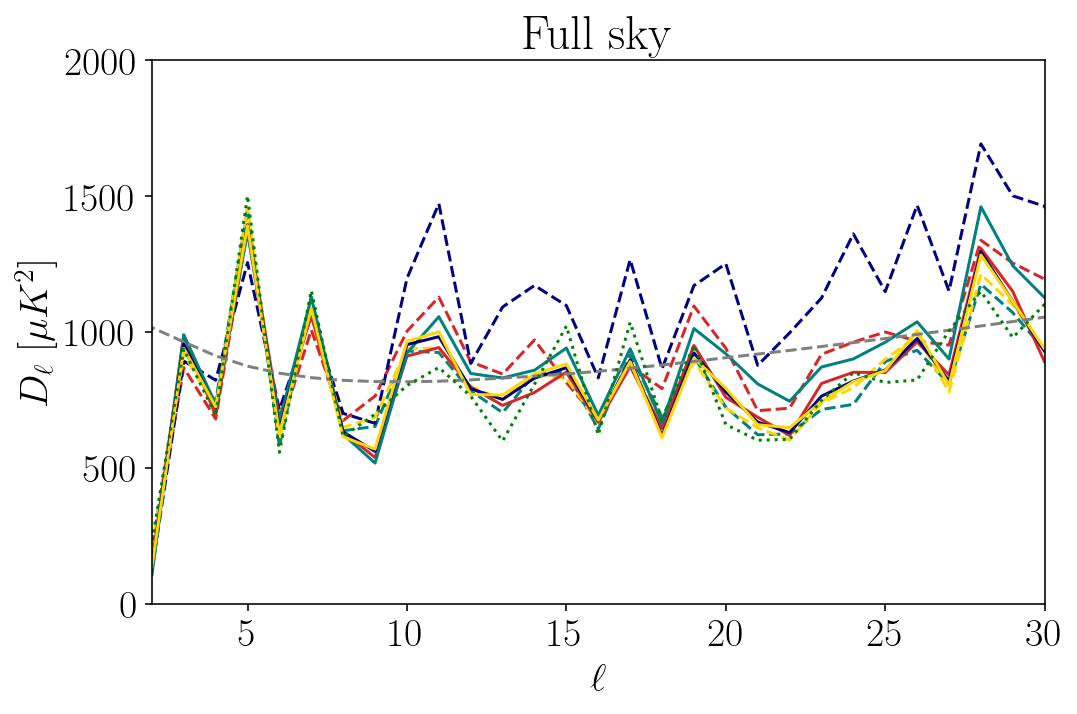

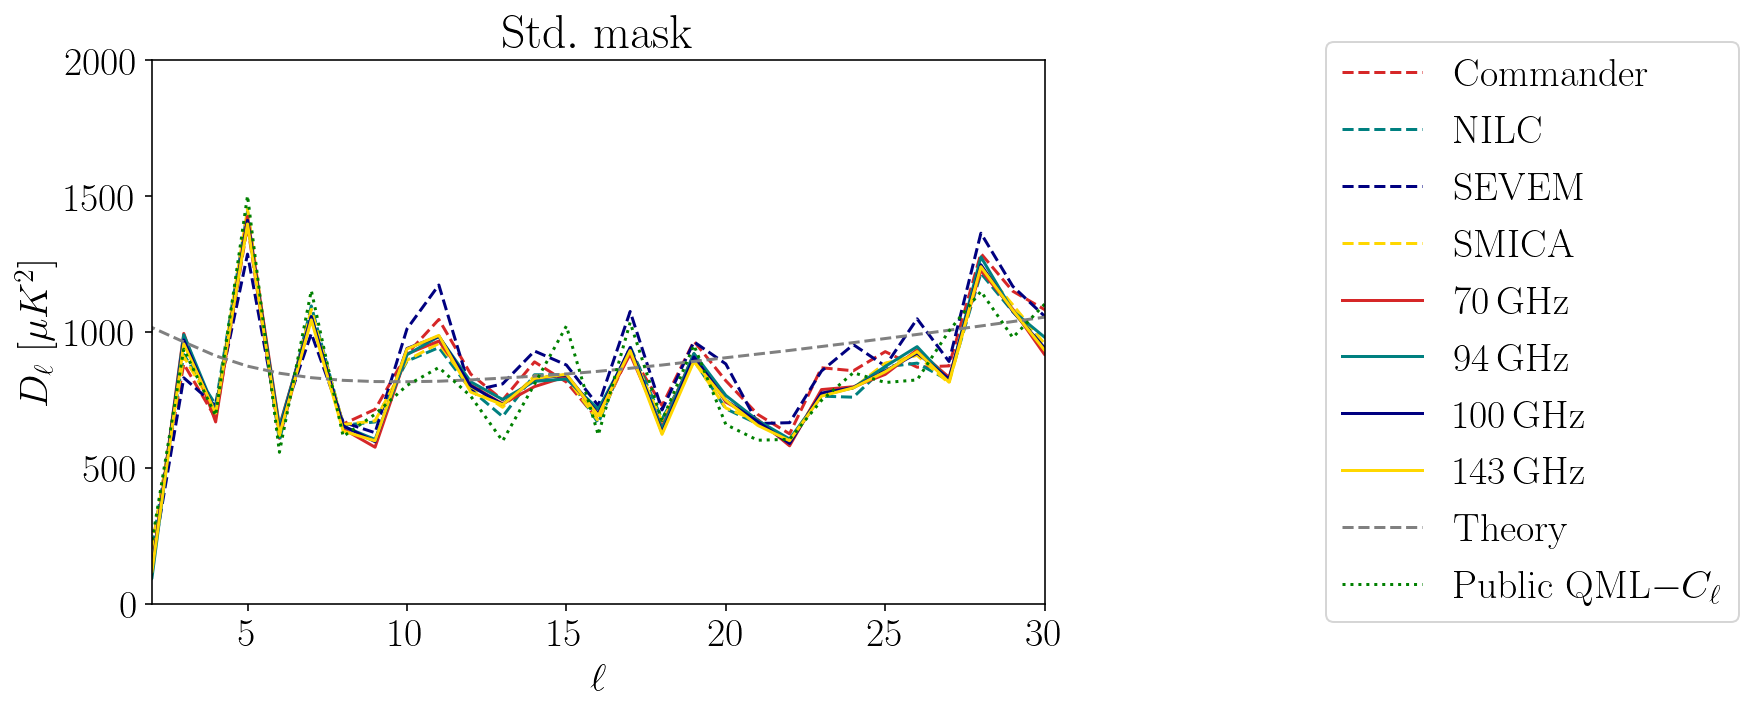

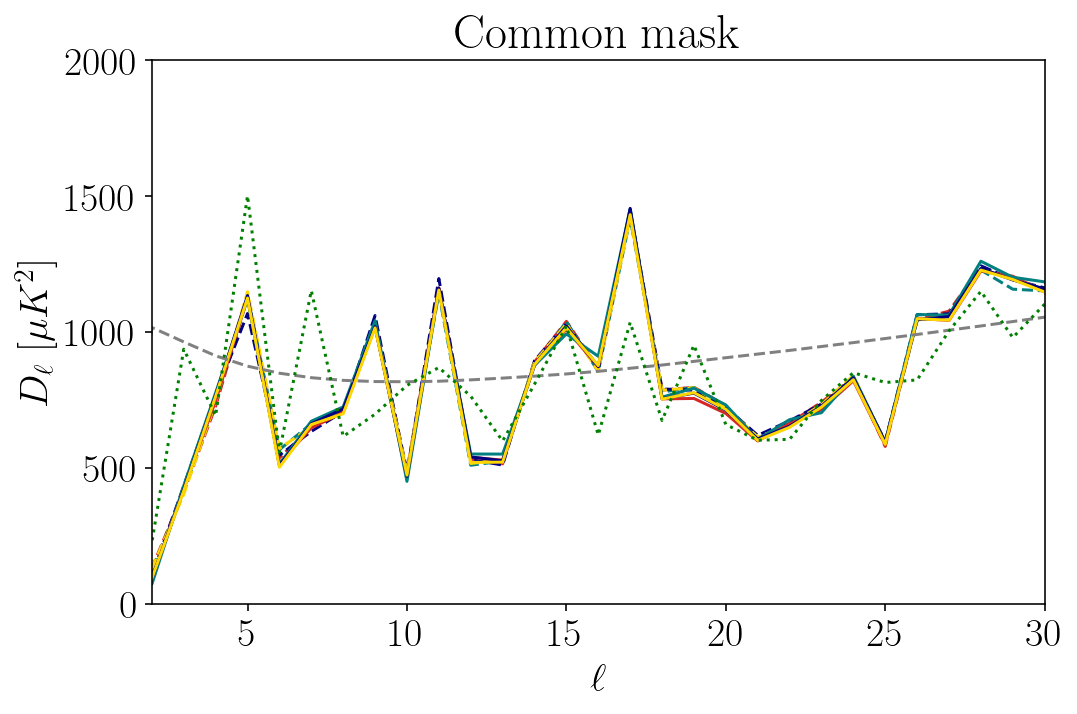

In [11]:
for m in range(Nmasks):
    fig = plt.figure(figsize=(8, 5))
    if m == 1:
        for n in range(4): plt.plot(ll, ll*(ll+1)*cl_Planck[m][n]/(2*np.pi), label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
        for n in range(4): plt.plot(ll, ll*(ll+1)*cl_debias[n]/(2*np.pi), label=labels_Planck[n+4], color=colors_Planck[n+4], ls=lss_Planck[n+4])    
    else:
        for n in range(Nmaps): plt.plot(ll, ll*(ll+1)*cl_Planck[m][n]/(2*np.pi), label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    plt.plot(ll, dl_theory, label=r"$\mathrm{Theory}$", color="grey", ls="--")
    plt.plot(ll, ll*(ll+1)*cl_qml/(2*np.pi), label=label_qml, color=color_qml, ls=":")
       
    plt.ylabel(r"$D_\ell\ [\mu K^2]$")
    plt.xlabel(r"$\ell$")
    plt.xlim(2,30)
    plt.ylim(0,2000)
    plt.title(labels_mask[m])
    #plt.legend(loc="lower right")
    if m==1: plt.legend(loc='center right', bbox_to_anchor=(1.8, 0.5))
    plt.savefig(f"Cl_{names_mask[m]}.pdf", format="PDF")
    plt.show()

## Plot $C(\theta)$

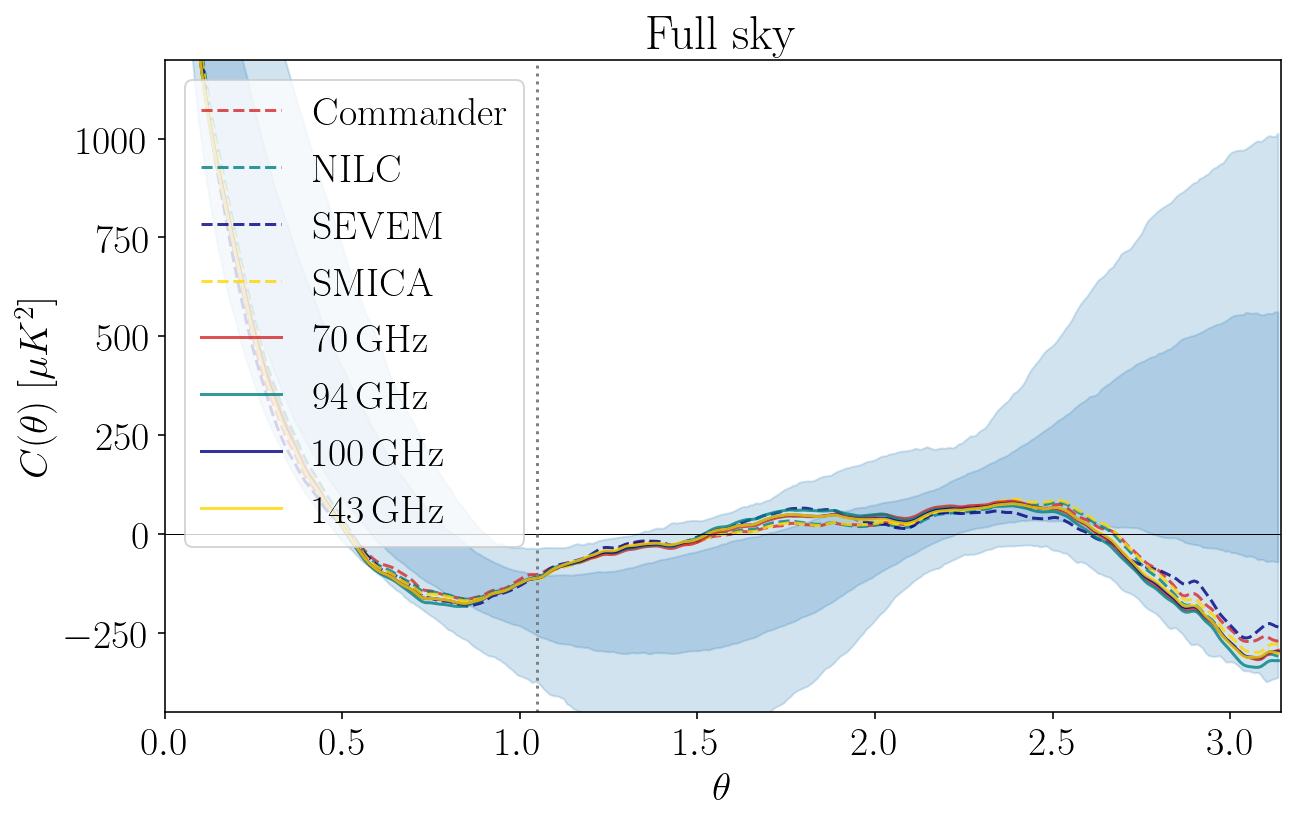

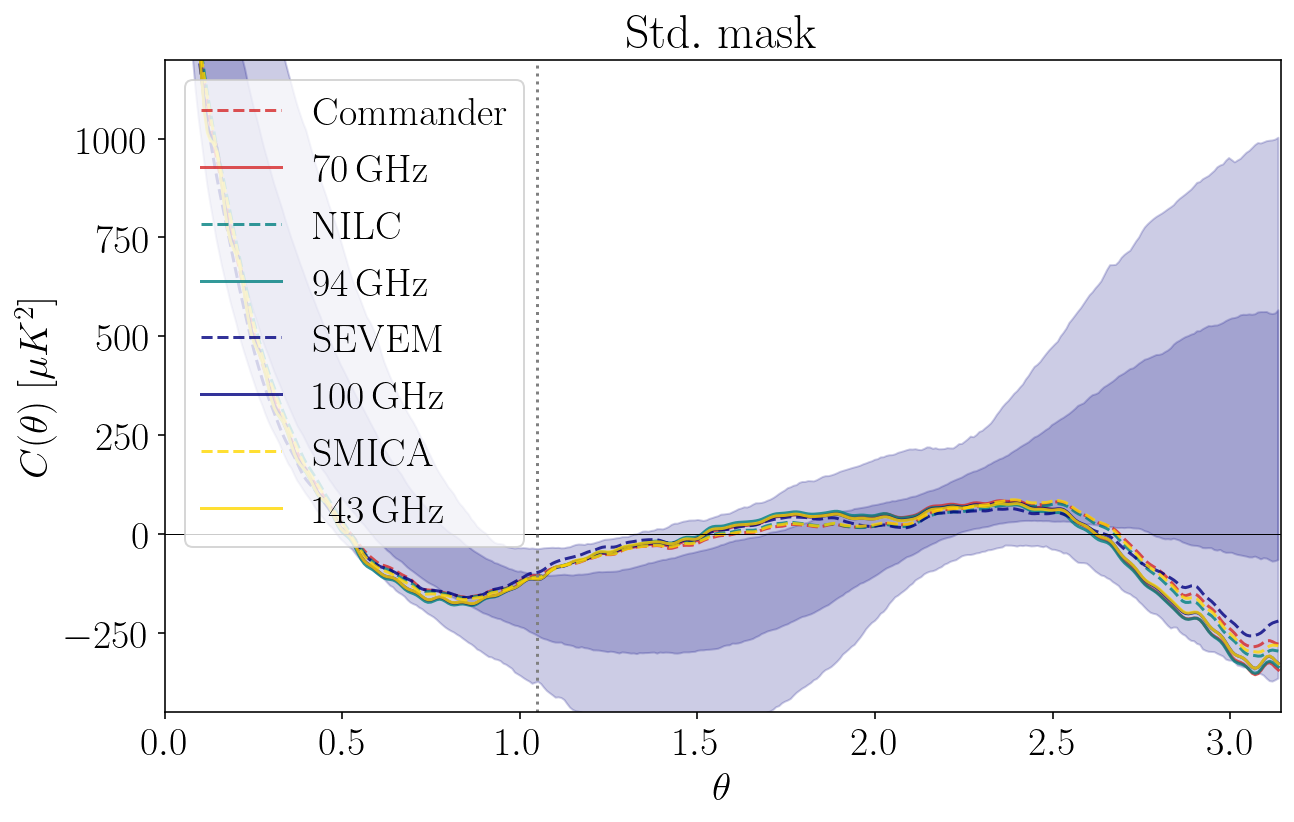

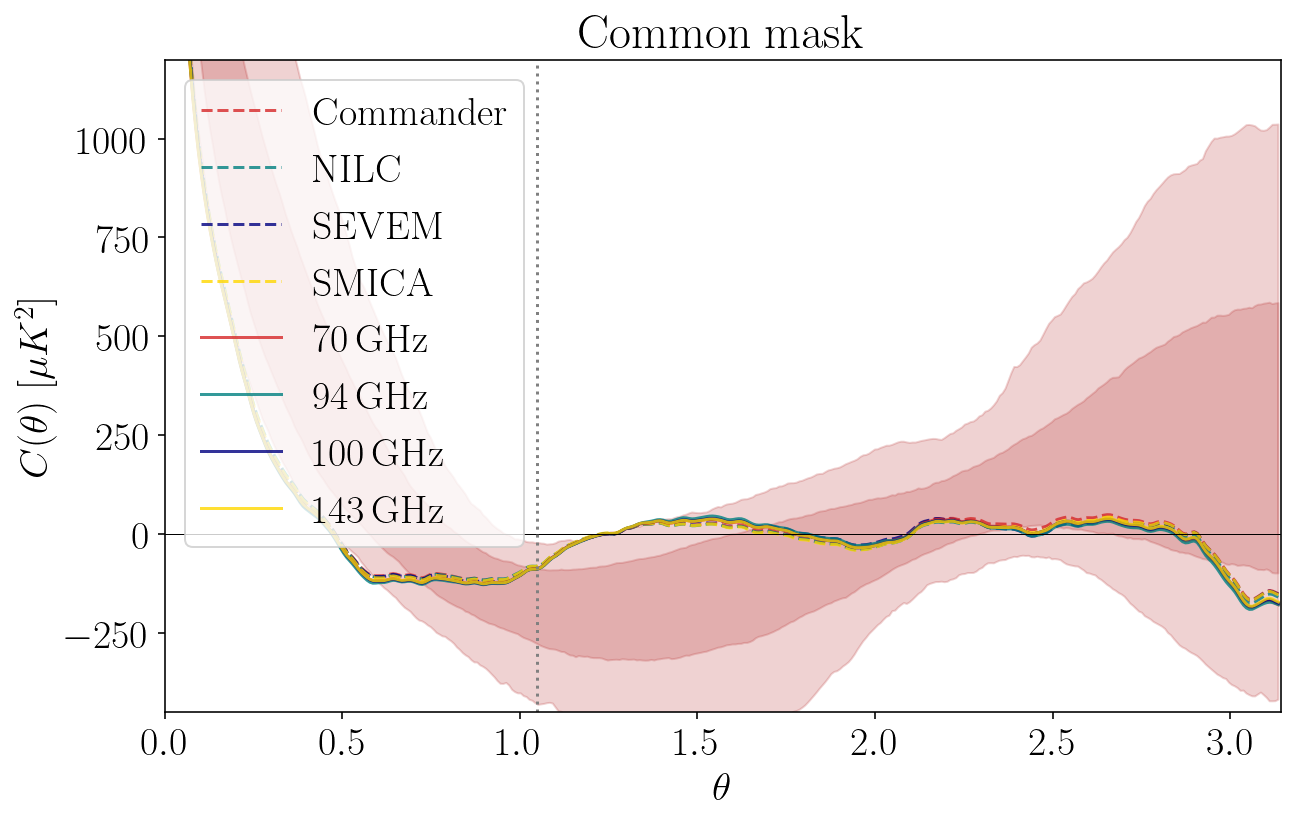

In [12]:
for m in range(Nmasks):
    fig = plt.figure(figsize=(10, 6))
    if m==1:
        for n in range(4):
            plt.plot(theta, corr_Planck[m][n], label=labels_Planck[n], ls=lss_Planck[n], color=colors_Planck[n], alpha=0.8)
            plt.plot(theta, corr_cl_debias[n], label=labels_Planck[n+4], ls=lss_Planck[n+4], color=colors_Planck[n+4], alpha=0.8)
    else:
        for n in range(Nmaps):
            plt.plot(theta, corr_Planck[m][n], label=labels_Planck[n], ls=lss_Planck[n], color=colors_Planck[n], alpha=0.8)

    plt.fill_between(theta, perc_68_lower[m], perc_68_upper[m], alpha= 0.2, color=colors_mask[m])
    plt.fill_between(theta, perc_95_lower[m], perc_95_upper[m], alpha= 0.2, color=colors_mask[m])
    plt.title(labels_mask[m])
    plt.ylim(-450, 1200)
    plt.xlim(0, np.pi)
    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$C(\theta)\ [\mu K^2]$")
    plt.axhline(0, color="black", lw=0.5)
    plt.axvline(60/180*np.pi, color="grey", ls=":")
    plt.legend()
    #plt.savefig(f"corr_{names_mask[m]}.pdf", format="PDF")
    plt.show()

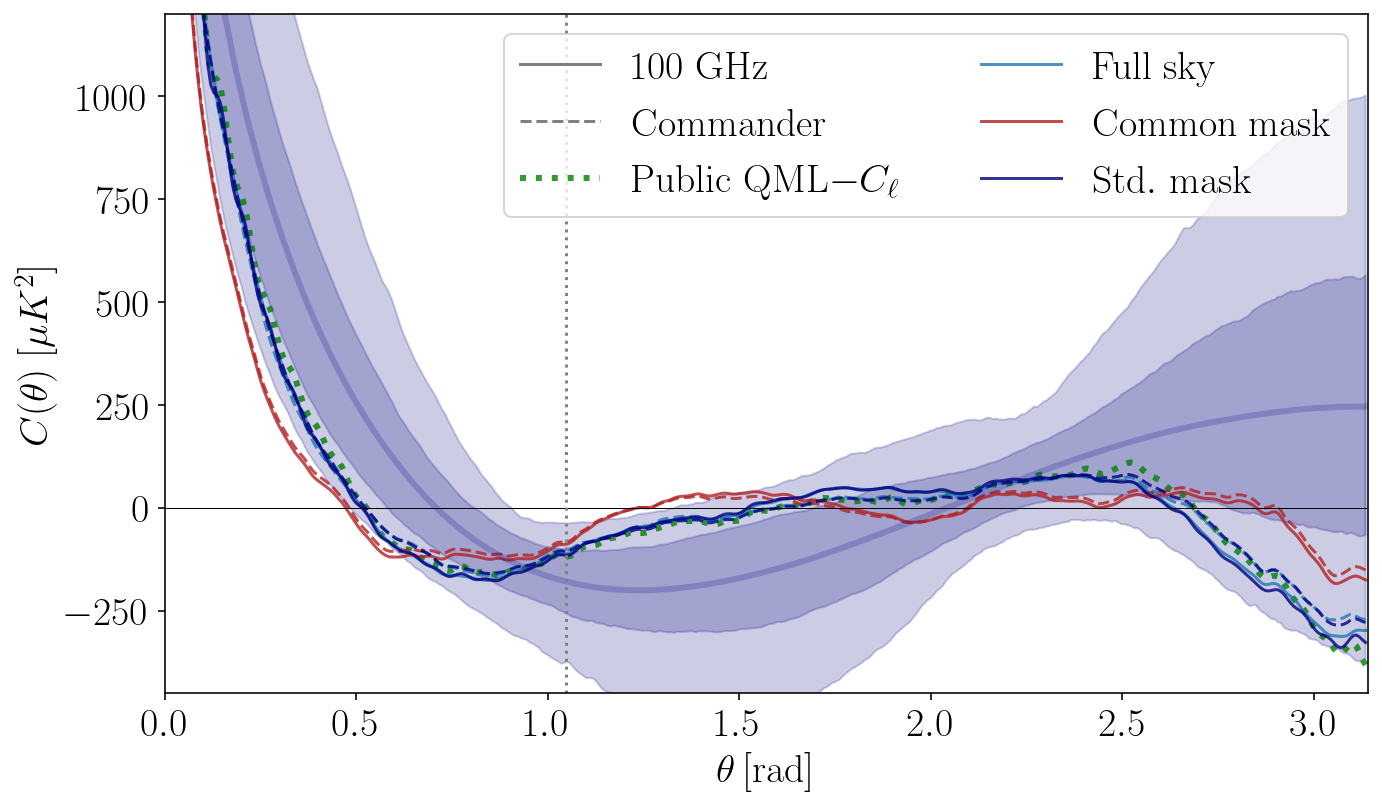

In [13]:
fig = plt.figure(figsize=(10, 6))
plt.plot([0], [0], color='grey', ls="-", label=r'$100\ \mathrm{GHz}$')
plt.plot([0], [0], color='grey', ls="--", label=r'$\mathrm{Commander}$')
plt.plot(theta, corr_qml, color=color_qml, alpha=0.8, ls=":", lw=3, label=label_qml)

for m in [0,2]:
    plt.plot(theta, corr_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, ls="-", label=labels_mask[m])
    plt.plot(theta, corr_Planck[m][index_Planck], color=colors_mask[m], alpha=0.8, ls="--")
for m in [1]:
    plt.plot(theta, corr_cl_debias[index_Hayley-4], color=colors_mask[m], alpha=0.8, ls="-", label=labels_mask[m])
    plt.plot(theta, corr_Planck[m][index_Planck], color=colors_mask[m], alpha=0.8, ls="--")
m = 1
plt.fill_between(theta, perc_68_lower[m], perc_68_upper[m], alpha= 0.2, color=colors_mask[m])
plt.fill_between(theta, perc_95_lower[m], perc_95_upper[m], alpha= 0.2, color=colors_mask[m])
#plt.plot(theta, corr_theory, color=colors_mask[m], ls="-", alpha=0.2, lw=3)
plt.plot(theta, mean_corrs[m], color=colors_mask[m], ls="-", alpha=0.2, lw=3)
plt.ylim(-450, 1200)
plt.xlim(0, np.pi)
plt.xlabel(r"$\theta\,\mathrm{[rad]}$")
plt.ylabel(r"$C(\theta)\ [\mu K^2]$")
plt.axhline(0, color="black", lw=0.5)
plt.axvline(60/180*np.pi, color="grey", ls=":")
plt.legend(loc="upper right", ncol=2)
plt.tight_layout()
#plt.savefig("Corr_fct.pdf", format="PDF")
plt.show()

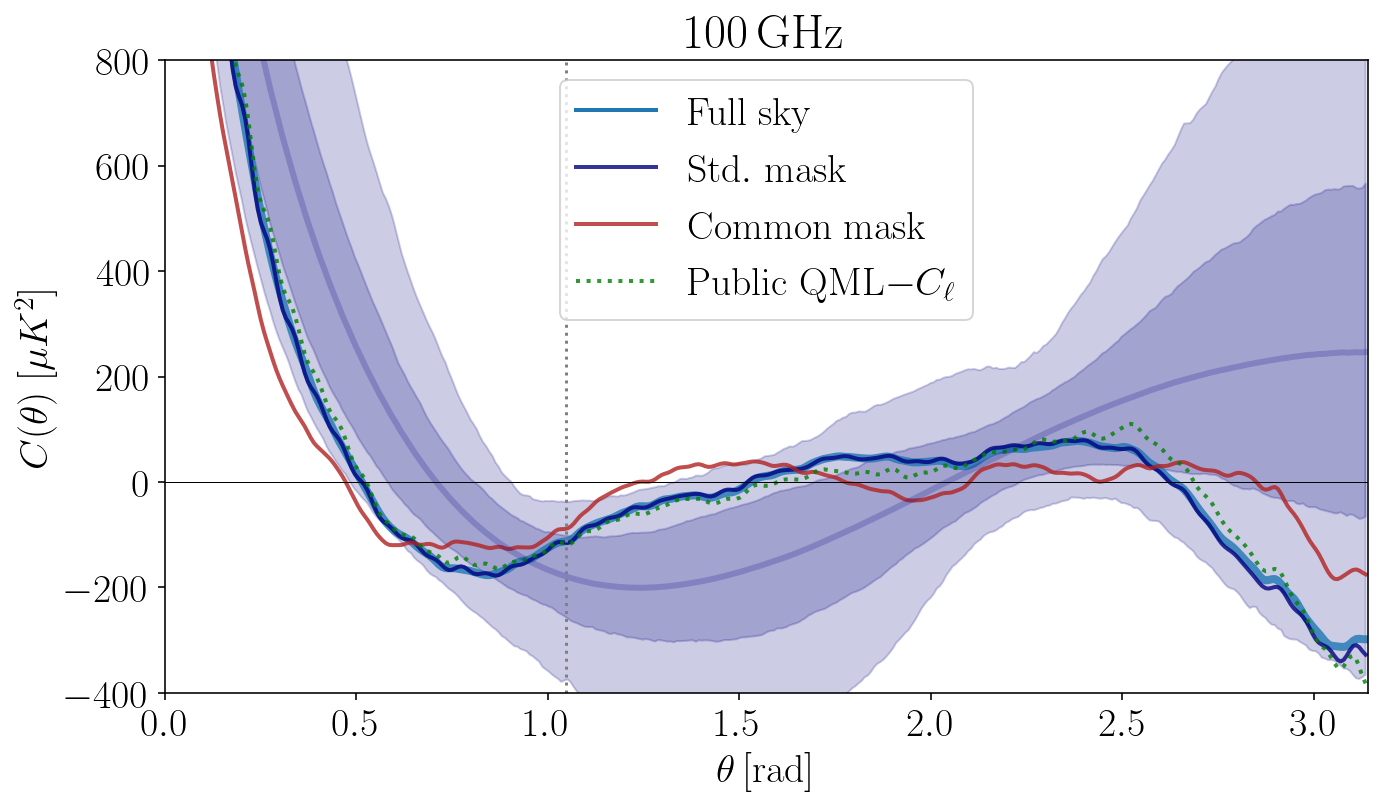

In [14]:
fig = plt.figure(figsize=(10, 6))
plt.title(labels_Planck[index_Hayley])
m = 0
plt.plot([0], [0], color=colors_mask[m], ls="-", label=labels_mask[m], lw=2)
plt.plot(theta, corr_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, ls="-", lw=4)
m = 1
plt.plot(theta, corr_cl_debias[index_Hayley-4], color=colors_mask[m], alpha=0.8, ls="-", label=labels_mask[m], lw=2)
m = 2
plt.plot(theta, corr_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, ls="-", label=labels_mask[m], lw=2)
m = 1
plt.fill_between(theta, perc_68_lower[m], perc_68_upper[m], alpha= 0.2, color=colors_mask[m])
plt.fill_between(theta, perc_95_lower[m], perc_95_upper[m], alpha= 0.2, color=colors_mask[m])
plt.plot(theta, corr_qml, color=color_qml, alpha=0.8, ls=":", lw=2, label=label_qml)
plt.plot(theta, mean_corrs[m], color=colors_mask[m], ls="-", alpha=0.2, lw=3)
plt.ylim(-400, 800)
plt.xlim(0, np.pi)
plt.xlabel(r"$\theta\,\mathrm{[rad]}$")
plt.ylabel(r"$C(\theta)\ [\mu K^2]$")
plt.axhline(0, color="black", lw=0.5)
plt.axvline(60/180*np.pi, color="grey", ls=":")
plt.legend(loc="upper center")
plt.tight_layout()
plt.savefig("corr_fct.pdf", format="PDF")
plt.show()

## Plot $S_{1/2}$

In [15]:
if load_stats_from_cluster: Smu_sims = [np.loadtxt(stats_dir+f"Smu_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)]
else:                       
    Smu_sims = [CMBanom.S_mu_many(corrs[m], cos_theta, 0.5, method) for m in range(Nmasks)]
    Smu_sims_simps = [CMBanom.S_mu_many(corrs[m], cos_theta, 0.5, "simps") for m in range(Nmasks)]
    Smu_sims_Itab = np.array([[CMBanom.S_mu_Itab(cls[m][n], 0.5) for n in range(Nsims)] for m in range(Nmasks)])

In [16]:
Smu_Planck = np.array([[CMBanom.S_mu(corr_Planck[m][n], cos_theta, 0.5, method) for n in range(Nmaps)] for m in range(Nmasks)])
Smu_debias = np.array([CMBanom.S_mu(corr_cl_debias[n], cos_theta, 0.5, method) for n in range(4)])
Smu_Planck_QML = CMBanom.S_mu_many([corr_qml], cos_theta, 0.5)

In [17]:
Smu_Planck_simps = np.array([[CMBanom.S_mu(corr_Planck[m][n], cos_theta, mu=0.5, method="simps") for n in range(Nmaps)] for m in range(Nmasks)])
Smu_Planck_Itab = np.array([[CMBanom.S_mu_Itab(cl_Planck[m][n], mu=0.5) for n in range(Nmaps)] for m in range(Nmasks)])

# Summation

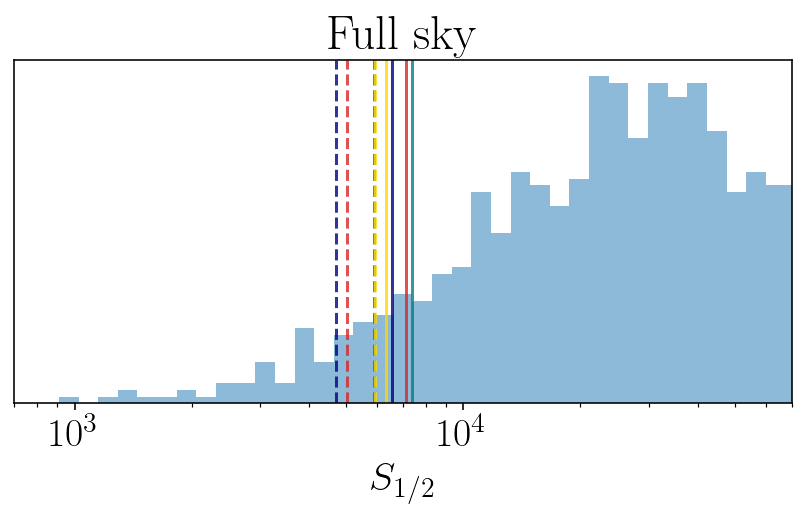

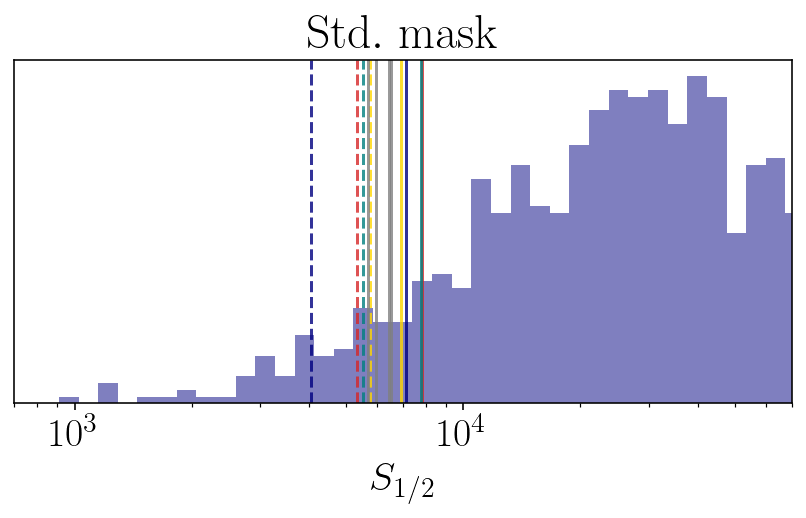

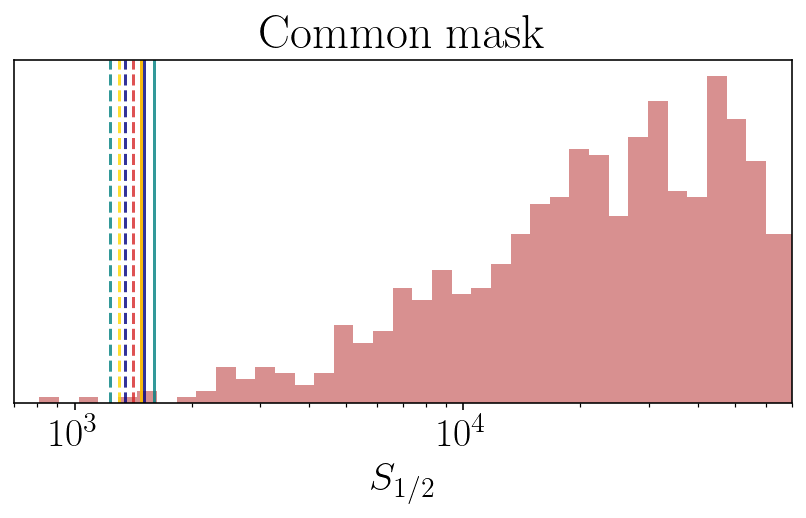

In [18]:
for m in range(Nmasks):
    bins = 10**np.linspace(2, 7, 100)
    h=plt.hist(Smu_sims[m], bins=bins, color=colors_mask[m], alpha=0.5)
    if m==1:
        for n in range(4): plt.axvline(Smu_Planck[m][n], color=colors_Planck[n], ls=lss_Planck[n], label=labels_Planck[n], alpha=0.8)
        for n in range(4): plt.axvline(Smu_Planck[m][n+4], color="grey", ls=lss_Planck[n+4], alpha=0.8)
        for n in range(4): plt.axvline(Smu_debias[n], color=colors_Planck[n+4], ls=lss_Planck[n+4], label=labels_Planck[n+4], alpha=0.8)
    else:
        for n in range(Nmaps): plt.axvline(Smu_Planck[m][n], color=colors_Planck[n], ls=lss_Planck[n], label=labels_Planck[n], alpha=0.8)
    plt.title(labels_mask[m])
    plt.xlim(7e2, 7e4)
    plt.xscale("log")
    plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
    plt.xlabel(r"$S_{1/2}$")
    #plt.legend(loc="lower right")
    plt.tight_layout()
    
    #if m==1: plt.legend(loc='center right', bbox_to_anchor=(2.8, 0.5), ncol=4)
    plt.savefig("hist_S_12_"+names_mask[m]+".pdf")
    plt.show()

# Simps integration

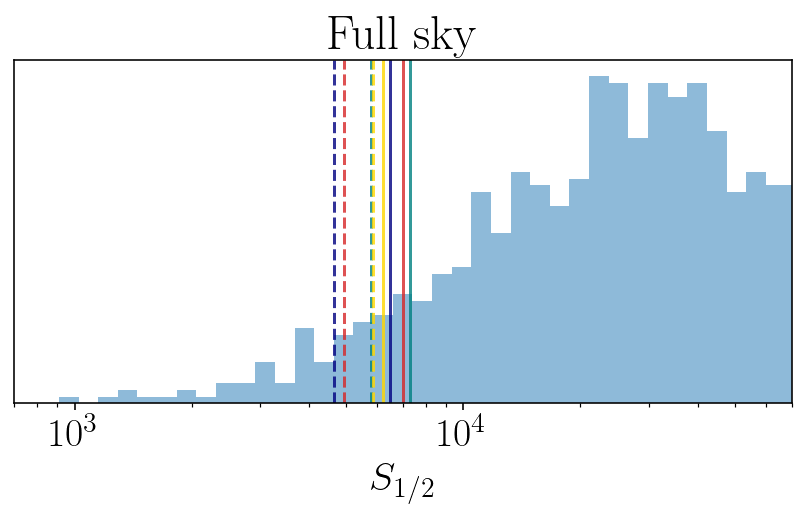

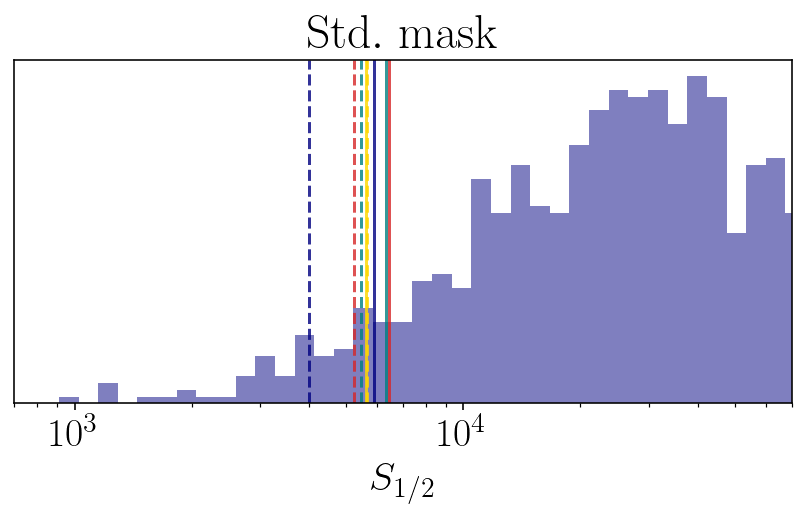

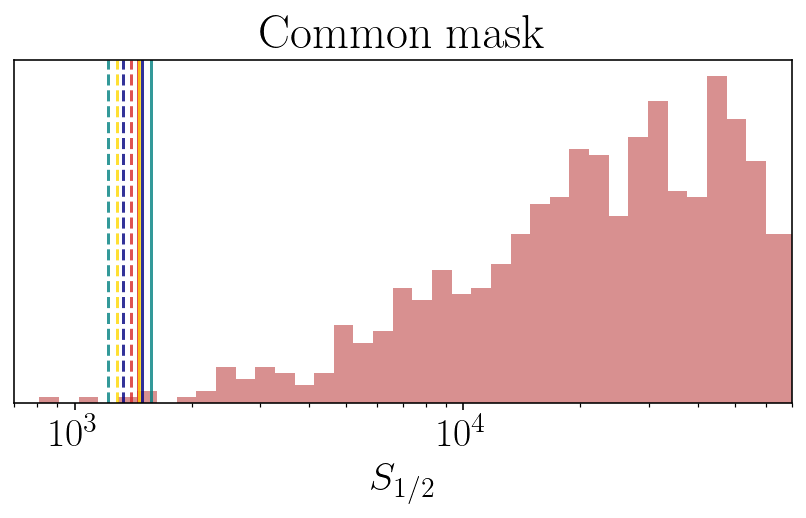

In [19]:
for m in range(Nmasks):
    bins = 10**np.linspace(2, 7, 100)
    h=plt.hist(Smu_sims_simps[m], bins=bins, color=colors_mask[m], alpha=0.5)
    for n in range(Nmaps): plt.axvline(Smu_Planck_simps[m][n], color=colors_Planck[n], ls=lss_Planck[n], label=labels_Planck[n], alpha=0.8)
    plt.title(labels_mask[m])
    plt.xlim(7e2, 7e4)
    plt.xscale("log")
    plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
    plt.xlabel(r"$S_{1/2}$")
    #plt.legend(loc="lower right")
    plt.tight_layout()
    
#    if m==1: plt.legend(loc='center right', bbox_to_anchor=(2.8, 0.5), ncol=4)
    plt.savefig("hist_S_12_"+names_mask[m]+".pdf")
    plt.show()

# Smu Itab

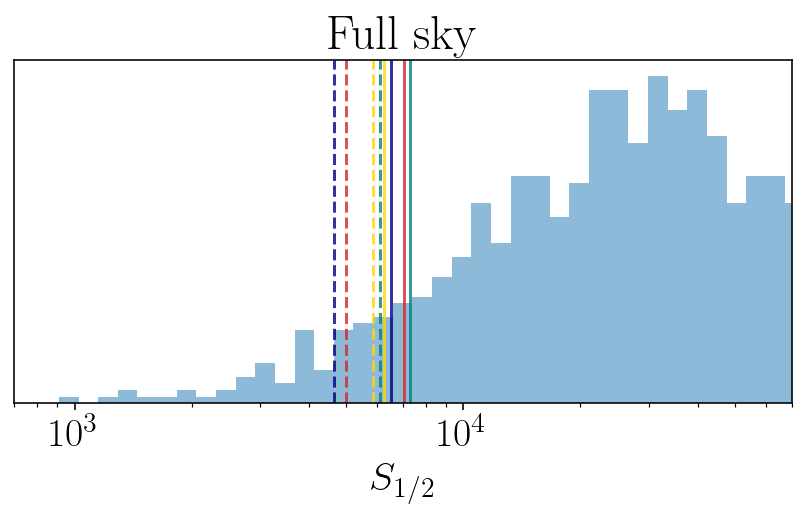

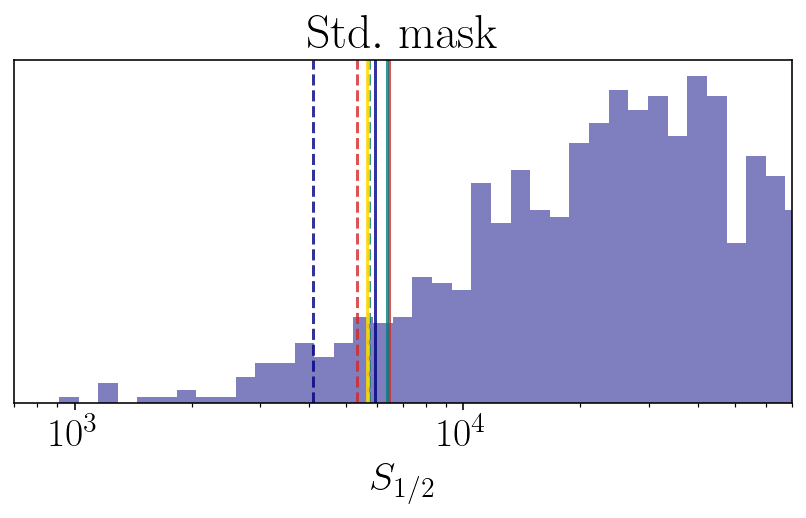

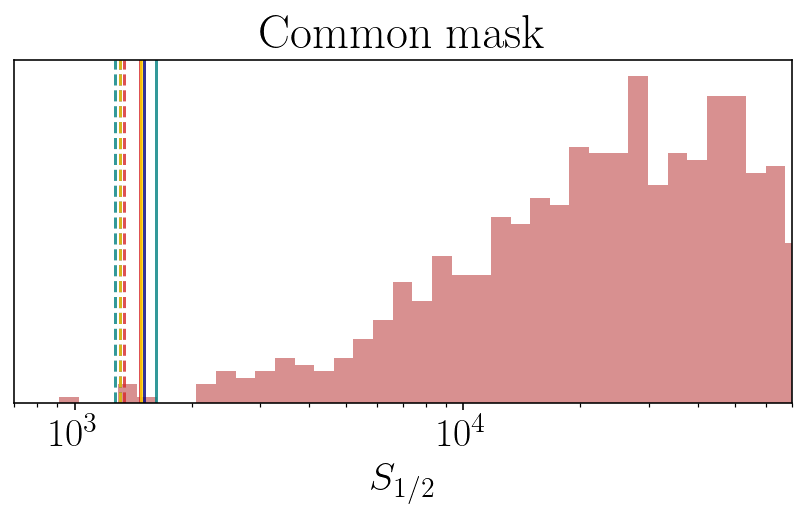

In [20]:
for m in range(Nmasks):
    bins = 10**np.linspace(2, 7, 100)
    h=plt.hist(Smu_sims_Itab[m], bins=bins, color=colors_mask[m], alpha=0.5)
    for n in range(Nmaps): plt.axvline(Smu_Planck_Itab[m][n], color=colors_Planck[n], ls=lss_Planck[n], label=labels_Planck[n], alpha=0.8)
    plt.title(labels_mask[m])
    plt.xlim(7e2, 7e4)
    plt.xscale("log")
    plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
    plt.xlabel(r"$S_{1/2}$")
    #plt.legend(loc="lower right")
    plt.tight_layout()
    
    #if m==1: plt.legend(loc='center right', bbox_to_anchor=(2.8, 0.5), ncol=4)
    plt.show()

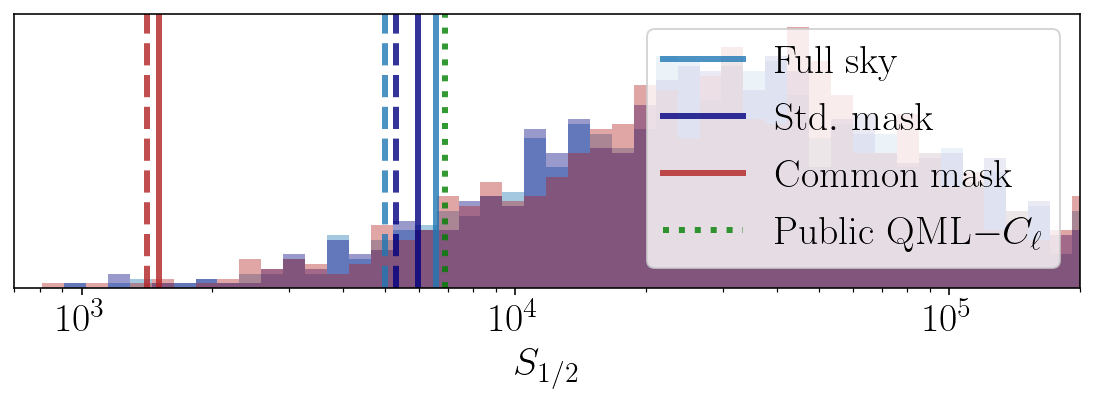

In [21]:
fig = plt.figure(figsize=(8, 3.2))
bins = 10**np.linspace(2, 7, 100)
#plt.plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
#plt.plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    h=plt.hist(Smu_sims[m], bins=bins, color=colors_mask[m], alpha=0.4)
    plt.axvline(Smu_Planck[m][index_Hayley], color=colors_mask[m], lw=3, alpha=0.8, ls="-", label=labels_mask[m])
    plt.axvline(Smu_Planck[m][index_Planck], color=colors_mask[m], lw=3, alpha=0.8, ls="--")
plt.axvline(Smu_Planck_QML[0], color=color_qml, lw=3, alpha=0.8, ls=":", label=label_qml)
plt.xlim(7e2, 2e5)
plt.xscale("log")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
plt.xlabel(r"$S_{1/2}$")
#plt.legend(loc='center right', bbox_to_anchor=(2.8, 0.5), ncol=1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("hist_S_12.pdf", format="PDF")
plt.show()

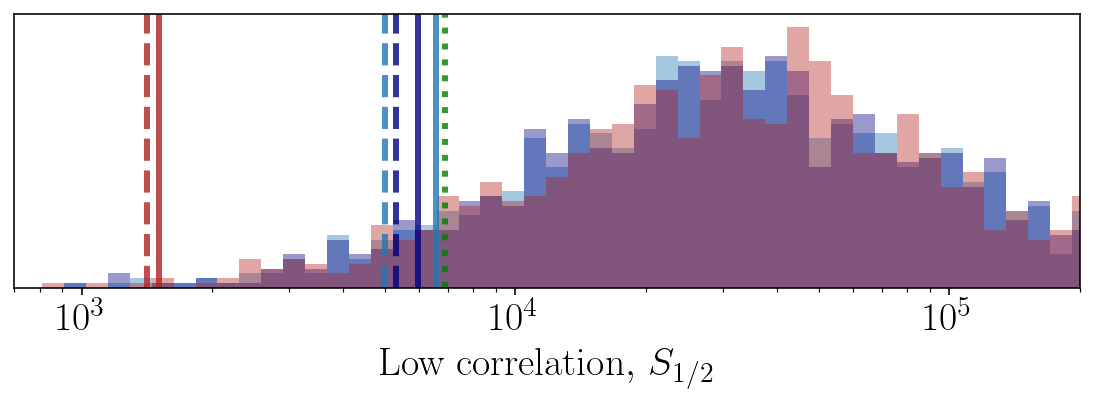

In [22]:
fig = plt.figure(figsize=(8, 3.2))
bins = 10**np.linspace(2, 7, 100)
plt.plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
plt.plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    h=plt.hist(Smu_sims[m], bins=bins, color=colors_mask[m], alpha=0.4)
    plt.axvline(Smu_Planck[m][index_Hayley], color=colors_mask[m], lw=3, alpha=0.8, ls="-")
    plt.axvline(Smu_Planck[m][index_Planck], color=colors_mask[m], lw=3, alpha=0.8, ls="--")
plt.axvline(Smu_Planck_QML[0], color=color_qml, lw=3, alpha=0.8, ls=":")
plt.xlim(7e2, 2e5)
plt.xscale("log")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
plt.xlabel(r"$\mathrm{Low\ correlation,\ } S_{1/2}$")
#plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("hist_S_12.pdf", format="PDF")
#plt.legend(loc='center right', bbox_to_anchor=(1.5, 0.5), ncol=1)
plt.show()

# Compute p-values (in %)

## Summation

In [23]:
print("-----------")
for m in range(Nmasks):
    print(names_mask[m])
    print("-----------")
    for n in range(Nmaps): print(f"{Smu_Planck[m][n]:.0f}, p = {100*CMBanom.pval_lower(Smu_Planck[m][n], Smu_sims[m]):.2f}% ({names_Planck[n]})")
    if m==1:
        for n in range(4): print(f"{Smu_debias[n]:.0f}, p = {100*CMBanom.pval_lower(Smu_debias[n], Smu_sims[m]):.2f}% ({names_cl_debias[n]})")
    print("-----------")

-----------
fullsky
-----------
5009, p = 4.90% (commander_nside_128)
5892, p = 6.40% (nilc_nside_128)
4690, p = 4.30% (sevem_nside_128)
5922, p = 6.60% (smica_nside_128)
7104, p = 8.50% (v9_70GHz_nside_128)
7375, p = 8.80% (v9_94GHz_nside_128)
6559, p = 7.60% (v9_100GHz_nside_128)
6321, p = 7.20% (v9_143GHz_nside_128)
-----------
stdmask
-----------
5315, p = 5.30% (commander_nside_128)
5526, p = 5.90% (nilc_nside_128)
4060, p = 3.40% (sevem_nside_128)
5742, p = 6.30% (smica_nside_128)
6521, p = 7.60% (v9_70GHz_nside_128)
6434, p = 7.40% (v9_94GHz_nside_128)
5968, p = 6.40% (v9_100GHz_nside_128)
5692, p = 6.20% (v9_143GHz_nside_128)
7847, p = 9.80% (70GHz_v9_OBSPdebias)
7763, p = 9.70% (94GHz_v9_OBSPdebias)
7121, p = 8.30% (100GHz_v9_OBSPdebias)
6927, p = 8.00% (143GHz_v9_OBSPdebias)
-----------
commask
-----------
1415, p = 0.30% (commander_nside_128)
1232, p = 0.20% (nilc_nside_128)
1351, p = 0.20% (sevem_nside_128)
1300, p = 0.20% (smica_nside_128)
1478, p = 0.40% (v9_70GHz_nside_1

## Simps integration

In [24]:
print("-----------")
for m in range(Nmasks):
    print(names_mask[m])
    print("-----------")
    for n in range(Nmaps): 
        print(f"{Smu_Planck_simps[m][n]:.0f}, p = {100*CMBanom.pval_lower(Smu_Planck_simps[m][n], Smu_sims_simps[m]):.2f}% ({names_Planck[n]})")
    print("-----------")

-----------
fullsky
-----------
4939, p = 4.80% (commander_nside_128)
5801, p = 6.20% (nilc_nside_128)
4633, p = 4.00% (sevem_nside_128)
5840, p = 6.20% (smica_nside_128)
7007, p = 8.10% (v9_70GHz_nside_128)
7268, p = 8.80% (v9_94GHz_nside_128)
6466, p = 7.50% (v9_100GHz_nside_128)
6229, p = 7.10% (v9_143GHz_nside_128)
-----------
stdmask
-----------
5242, p = 5.10% (commander_nside_128)
5441, p = 5.60% (nilc_nside_128)
4003, p = 3.10% (sevem_nside_128)
5662, p = 6.10% (smica_nside_128)
6426, p = 7.30% (v9_70GHz_nside_128)
6338, p = 7.20% (v9_94GHz_nside_128)
5880, p = 6.40% (v9_100GHz_nside_128)
5608, p = 6.10% (v9_143GHz_nside_128)
-----------
commask
-----------
1399, p = 0.20% (commander_nside_128)
1215, p = 0.20% (nilc_nside_128)
1335, p = 0.20% (sevem_nside_128)
1284, p = 0.20% (smica_nside_128)
1457, p = 0.40% (v9_70GHz_nside_128)
1576, p = 0.50% (v9_94GHz_nside_128)
1492, p = 0.40% (v9_100GHz_nside_128)
1463, p = 0.40% (v9_143GHz_nside_128)
-----------


## Smu Itab

In [25]:
print("-----------")
for m in range(Nmasks):
    print(names_mask[m])
    print("-----------")
    for n in range(Nmaps): 
        print(f"{Smu_Planck_Itab[m][n]:.0f}, p = {100*CMBanom.pval_lower(Smu_Planck_Itab[m][n], Smu_sims_Itab[m]):.2f}% ({names_Planck[n]})")
    print("-----------")

-----------
fullsky
-----------
4998, p = 4.90% (commander_nside_128)
6100, p = 7.10% (nilc_nside_128)
4660, p = 4.20% (sevem_nside_128)
5870, p = 6.40% (smica_nside_128)
7037, p = 8.30% (v9_70GHz_nside_128)
7303, p = 8.90% (v9_94GHz_nside_128)
6496, p = 7.50% (v9_100GHz_nside_128)
6260, p = 7.20% (v9_143GHz_nside_128)
-----------
stdmask
-----------
5314, p = 5.30% (commander_nside_128)
5716, p = 6.20% (nilc_nside_128)
4097, p = 3.40% (sevem_nside_128)
5689, p = 6.20% (smica_nside_128)
6453, p = 7.60% (v9_70GHz_nside_128)
6365, p = 7.30% (v9_94GHz_nside_128)
5907, p = 6.40% (v9_100GHz_nside_128)
5634, p = 6.10% (v9_143GHz_nside_128)
-----------
commask
-----------
1338, p = 0.20% (commander_nside_128)
1270, p = 0.10% (nilc_nside_128)
1306, p = 0.10% (sevem_nside_128)
1307, p = 0.10% (smica_nside_128)
1471, p = 0.40% (v9_70GHz_nside_128)
1616, p = 0.50% (v9_94GHz_nside_128)
1512, p = 0.40% (v9_100GHz_nside_128)
1481, p = 0.40% (v9_143GHz_nside_128)
-----------


In [26]:
print("p-values")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{100*CMBanom.pval_lower(Smu_Planck[m][n],Smu_sims[m]):.2f} ", end="")
    print("\\\\")

p-values
fullsky : &4.90 &6.40 &4.30 &6.60 &8.50 &8.80 &7.60 &7.20 \\
stdmask : &5.30 &5.90 &3.40 &6.30 &7.60 &7.40 &6.40 &6.20 \\
commask : &0.30 &0.20 &0.20 &0.20 &0.40 &0.50 &0.50 &0.40 \\


In [27]:
print("stats")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{Smu_Planck[m][n]:.0f} ", end="")
    print("\\\\")

stats
fullsky : &5009 &5892 &4690 &5922 &7104 &7375 &6559 &6321 \\
stdmask : &5315 &5526 &4060 &5742 &6521 &6434 &5968 &5692 \\
commask : &1415 &1232 &1351 &1300 &1478 &1597 &1511 &1482 \\
